In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# Load dataset
df = pd.read_csv("medicinal_plants_100k_dataset.csv")

In [3]:
# Encode the crop labels
label_encoder = LabelEncoder()
df["Crop"] = label_encoder.fit_transform(df["Crop"])

# Split features and target variable
X = df.drop(columns=["Crop"])
y = df["Crop"]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# Split dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define Deep Learning model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(len(label_encoder.classes_), activation='softmax')  # Output layer
])

In [24]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test), verbose=1)

Epoch 1/20
774/774 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7255 - loss: 0.7401 - val_accuracy: 0.8932 - val_loss: nan
Epoch 2/20
774/774 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8812 - loss: 0.2980 - val_accuracy: 0.9107 - val_loss: nan
Epoch 3/20
774/774 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8978 - loss: 0.2568 - val_accuracy: 0.9145 - val_loss: nan
Epoch 4/20
774/774 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9040 - loss: 0.2372 - val_accuracy: 0.9158 - val_loss: nan
Epoch 5/20
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9066 - loss: 0.2266 - val_accuracy: 0.9171 - val_loss: nan
Epoch 6/20
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9092 - loss: 0.2153 - val_accuracy: 0.9224 - val_loss: nan
Epoch 7/20
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9173 - loss: 0.1951 - val_accuracy: 0.9265 - val_loss: nan
Epoch 8/20
774/774 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9163 - loss: 0.1931 - val_accuracy: 0.9296 - val_loss: nan


In [ ]:
# Evaluate model performance
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 93.69%


In [ ]:
# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

387/387 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


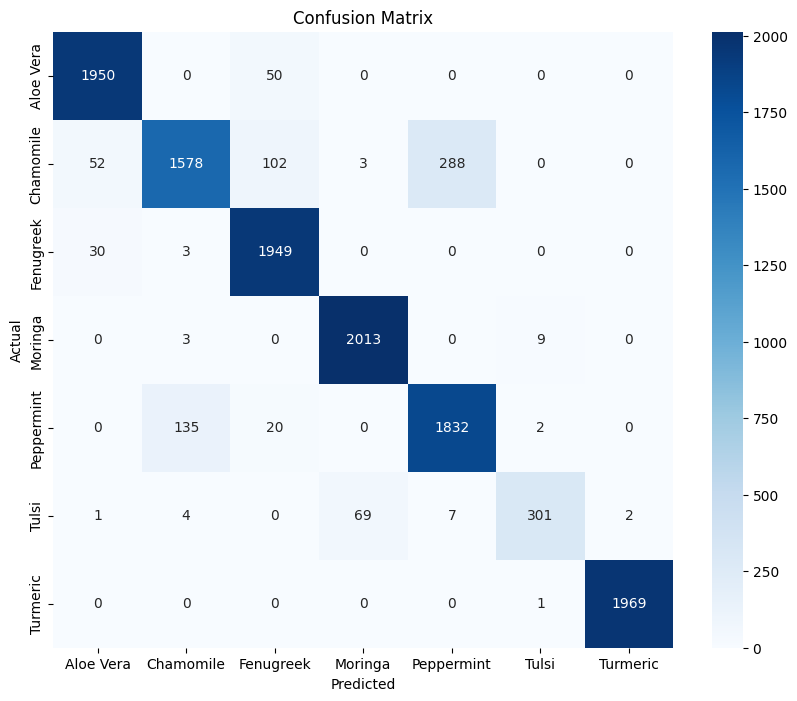

              precision    recall  f1-score   support

   Aloe Vera       0.96      0.97      0.97      2000
   Chamomile       0.92      0.78      0.84      2023
   Fenugreek       0.92      0.98      0.95      1982
     Moringa       0.97      0.99      0.98      2025
  Peppermint       0.86      0.92      0.89      1989
       Tulsi       0.96      0.78      0.86       384
    Turmeric       1.00      1.00      1.00      1970

    accuracy                           0.94     12373
   macro avg       0.94      0.92      0.93     12373
weighted avg       0.94      0.94      0.94     12373



In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_classes, target_names=label_encoder.classes_))

In [ ]:
model.save("/content/deep_learning_medicinal_plants_model.h5")

In [6]:
from tensorflow.keras.models import load_model
loaded_model = load_model("deep_learning_medicinal_plants_model.h5")

In [7]:
import numpy as np



static_input = np.array([[10.5, 3.2, 5.6, 25.0, 70.0, 800.0]])  # Example values
static_input_scaled = scaler.transform(static_input)

prediction = loaded_model.predict(static_input_scaled)
predicted_class = np.argmax(prediction, axis=1)
predicted_crop = label_encoder.inverse_transform(predicted_class)

print(f"Predicted Crop: {predicted_crop[0]}")

c:\Users\My PC\Desktop\deep learning Model\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step
Predicted Crop: Lemongrass


In [ ]:

import numpy as np
# Values taken from Firebase
sensor_data = {
    'Humidity': 41,
    'LightCondition': 'Low Light',  
    'Nitrogen': 21504,
    'Phosphorus': 0,
    'Potassium': 0,
    'SoilHumidity': 358.4,  
    'SoilPH': 0.0,  
    'SoilTemperature': 640.1,  
    'TDS_Value': 253,  
    'Temperature': 28
}

# Static input array
static_input = np.array([[sensor_data['Nitrogen'], sensor_data['Phosphorus'], sensor_data['Potassium'], 
                          sensor_data['Temperature'], sensor_data['Humidity'], 0]]) 
# Scale the input using the trained scaler
static_input_scaled = scaler.transform(static_input)

# Predict the output
prediction = loaded_model.predict(static_input_scaled)
predicted_class = np.argmax(prediction, axis=1)

# Decode the predicted class using the label encoder
predicted_crop = label_encoder.inverse_transform(predicted_class)

print(f"Predicted Crop: {predicted_crop[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Predicted Crop: Neem


c:\Users\My PC\Desktop\deep learning Model\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [15]:
static_input = np.array([[40.68, 39.89, 65.45, 30.46, 62.00, 342.59]])  # Example values for Moringa

# Scale the input using the trained scaler
static_input_scaled = scaler.transform(static_input)

# Predict the output
prediction = loaded_model.predict(static_input_scaled)
predicted_class = np.argmax(prediction, axis=1)

# Decode the predicted class using the label encoder
predicted_crop = label_encoder.inverse_transform(predicted_class)

print(f"Predicted Crop: {predicted_crop[0]}")

c:\Users\My PC\Desktop\deep learning Model\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Crop: Aloe Vera


In [5]:
import joblib

# Save the scaler after training
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [6]:
import pickle

# Save label encoder after encoding labels
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)



In [8]:
from tensorflow.keras.models import load_model
import joblib
import pickle

# Load the model
model = load_model("deep_learning_medicinal_plants_model.h5", compile=False)


# Load the scaler
scaler = joblib.load("scaler.pkl")

# Load the label encoder
with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)


In [10]:
import firebase_admin
from firebase_admin import credentials, db

if not firebase_admin._apps:
    cred = credentials.Certificate("your-service-account.json")  # Path to your Firebase admin SDK
    firebase_admin.initialize_app(cred, {
        'databaseURL': 'https://fyp2-1d3a2-default-rtdb.firebaseio.com'
    })


In [11]:
firebase_admin.initialize_app(cred, {
    'databaseURL': 'https://your-db.firebaseio.com'
}, name='customApp1')

In [13]:
import firebase_admin
from firebase_admin import credentials, db
import numpy as np
import joblib
import pickle
from tensorflow.keras.models import load_model

# Initialize Firebase (only if not already initialized)
if not firebase_admin._apps:
    cred = credentials.Certificate("vform.json")  # Replace with your JSON file
    firebase_admin.initialize_app(cred, {
        'databaseURL': 'https://fyp2-1d3a2-default-rtdb.firebaseio.com'
    })

# Load model, scaler, and label encoder
model = load_model("deep_learning_medicinal_plants_model.h5")
scaler = joblib.load("scaler.pkl")

with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

# Get data from Firebase (replace the path with your actual structure)
ref = db.reference('/sensorData')  # Adjust this path to match your DB structure
sensor_data = ref.get()

# Example: ensure keys match your model's features
data = [
    sensor_data.get('Nitrogen', 0),
    sensor_data.get('Phosphorus', 0),
    sensor_data.get('Potassium', 0),
    sensor_data.get('Temperature', 0),
    sensor_data.get('Humidity', 0),
    0  # e.g., LightIntensity or other placeholder
]

static_input = np.array([data])
static_input_scaled = scaler.transform(static_input)

# Predict
prediction = model.predict(static_input_scaled)
predicted_class = np.argmax(prediction, axis=1)
predicted_crop = label_encoder.inverse_transform(predicted_class)

print(f"Predicted Crop: {predicted_crop[0]}")


AttributeError: 'NoneType' object has no attribute 'get'

In [14]:
print("Fetched data from Firebase:", sensor_data)


Fetched data from Firebase: None
